# 📊 Notebook 02 — Exploratory Data Analysis (EDA)

**Purpose:** Build a clear, business-oriented understanding of the cleaned Kickstarter dataset, justify key data decisions, and motivate the features used later in the modelling pipeline.

This version keeps the original notebook structure and strengthens it with:
- a **drop audit** (what was removed and why),
- a **missingness + imputation rationale**,
- a **post-drop temporal cut justification**,
- richer EDA on **location, text, and engineered patterns**,
- and a **split/stratification audit** to keep the pipeline methodologically sound.

## Setup — Imports, Paths, and Helper Functions

In [1]:
import os
import glob
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_PATH = "../data/Kickstarter_2026-02-12T03_20_22_018Z"
OUTPUTS_PATH = "data"   # reads from notebook 01 outputs
FIGURES_PATH = os.path.join(OUTPUTS_PATH, "figures")
os.makedirs(FIGURES_PATH, exist_ok=True)

SUCCESS_COLOR = "#3B82F6"
FAILURE_COLOR = "#EF4444"
NEUTRAL_COLOR = "#6B7280"
PALETTE = {1: SUCCESS_COLOR, 0: FAILURE_COLOR}

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

# ── Load cleaned data from Notebook 01 ─────────────────────────────────────
df = pd.read_parquet(os.path.join(OUTPUTS_PATH, "clean_df.parquet")).copy()

# Parse key columns defensively
for col in ["launched_at", "deadline", "created_at", "goal"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "launched_at" in df.columns:
    df["launched_dt"] = pd.to_datetime(df["launched_at"], unit="s", utc=True)
if "deadline" in df.columns:
    df["deadline_dt"] = pd.to_datetime(df["deadline"], unit="s", utc=True)
if "created_at" in df.columns:
    df["created_dt"] = pd.to_datetime(df["created_at"], unit="s", utc=True)

# Small helpers to keep the notebook readable
def pct(x):
    return f"{100*x:.1f}%"

def add_value_labels(ax, fmt="{:,.0f}", pad=0.01):
    y_max = ax.get_ylim()[1]
    for patch in ax.patches:
        val = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            val + y_max * pad,
            fmt.format(val),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

def safe_json_get(val, key, default=None):
    try:
        if pd.isna(val):
            return default
        parsed = json.loads(str(val).replace("'", '"'))
        return parsed.get(key, default)
    except Exception:
        match = re.search(rf'"{re.escape(key)}"\s*:\s*"([^"]*)"', str(val))
        return match.group(1) if match else default

print(f"Clean dataframe shape: {df.shape}")
print(f"Launch date range    : {df['launched_dt'].min()} → {df['launched_dt'].max()}")
print(f"Overall success rate : {pct(df['success'].mean())}")

Clean dataframe shape: (188429, 21)
Launch date range    : 2009-04-25 15:36:21+00:00 → 2026-02-06 20:48:03+00:00
Overall success rate : 62.4%


## Section 1 — Data Snapshot

Before going into charts, we establish the **basic profile of the final cleaned dataset** that enters the modelling workflow.

In [2]:
snapshot = pd.DataFrame({
    "metric": [
        "Rows",
        "Columns",
        "Date min",
        "Date max",
        "Successful campaigns",
        "Failed campaigns",
        "Overall success rate",
    ],
    "value": [
        f"{len(df):,}",
        f"{df.shape[1]:,}",
        str(df["launched_dt"].min().date()),
        str(df["launched_dt"].max().date()),
        f"{int(df['success'].sum()):,}",
        f"{int((1 - df['success']).sum()):,}",
        pct(df["success"].mean()),
    ]
})
snapshot

,metric,value
0,Rows,"188,429"
1,Columns,21
2,Date min,2009-04-25
3,Date max,2026-02-06
4,Successful campaigns,"117,627"
5,Failed campaigns,"70,802"
6,Overall success rate,62.4%


## Section 2 — What We Dropped and Why We Dropped It

This project involves a **large data reduction**, so it is important to make the logic explicit rather than treating cleaning as a black box.

The main reasons for dropping data are:

1. **Duplicate campaigns**: the raw export is sharded and can contain repeated `id`s.
2. **Non-binary outcomes**: campaigns that are not clearly `successful` or `failed` are not suitable for our binary target.
3. **Leakage columns**: variables such as `pledged`, `backers_count`, `percent_funded`, or `spotlight` are only known after or very near campaign outcome.
4. **Metadata / junk columns**: URLs, nested JSON blobs, and UI flags add complexity without predictive value in their raw form.

The cell below reconstructs the main drop logic using the raw CSV shards when they are available locally. That gives us a transparent audit trail for the final dataset.

In [3]:
LEAKAGE_COLS = [
    "pledged", "usd_pledged", "converted_pledged_amount",
    "backers_count", "percent_funded", "spotlight",
    "state_changed_at", "usd_exchange_rate", "static_usd_rate", "fx_rate",
]

JUNK_COLS = [
    "photo", "profile", "urls", "creator", "source_url", "slug",
    "currency_symbol", "currency_trailing_code", "current_currency",
    "is_liked", "is_disliked", "is_starrable",
    "is_in_post_campaign_pledging_phase", "usd_type", "prelaunch_activated",
    "category", "location",
]

drop_audit_rows = []

raw_files = sorted(glob.glob(os.path.join(DATA_PATH, "Kickstarter*.csv")))
if raw_files:
    raw_parts = [pd.read_csv(fp, low_memory=False) for fp in raw_files]
    raw_df = pd.concat(raw_parts, ignore_index=True)

    n0_rows, n0_cols = raw_df.shape
    drop_audit_rows.append({
        "step": "Raw concatenated data",
        "rows_remaining": n0_rows,
        "rows_removed_this_step": 0,
        "cols_remaining": n0_cols,
        "cols_removed_this_step": 0,
        "reason": "All raw CSV shards merged"
    })

    dedup_df = raw_df.drop_duplicates(subset=["id"]).copy()
    drop_audit_rows.append({
        "step": "Deduplicate on id",
        "rows_remaining": len(dedup_df),
        "rows_removed_this_step": n0_rows - len(dedup_df),
        "cols_remaining": dedup_df.shape[1],
        "cols_removed_this_step": 0,
        "reason": "Same campaign can appear in multiple shards"
    })

    binary_df = dedup_df[dedup_df["state"].isin(["successful", "failed"])].copy()
    drop_audit_rows.append({
        "step": "Keep only successful / failed campaigns",
        "rows_remaining": len(binary_df),
        "rows_removed_this_step": len(dedup_df) - len(binary_df),
        "cols_remaining": binary_df.shape[1],
        "cols_removed_this_step": 0,
        "reason": "Needed for a clean binary target"
    })

    cols_after_leakage = [c for c in binary_df.columns if c not in LEAKAGE_COLS]
    leakage_df = binary_df[cols_after_leakage].copy()
    drop_audit_rows.append({
        "step": "Drop leakage columns",
        "rows_remaining": len(leakage_df),
        "rows_removed_this_step": 0,
        "cols_remaining": leakage_df.shape[1],
        "cols_removed_this_step": binary_df.shape[1] - leakage_df.shape[1],
        "reason": "Columns unavailable or unsafe at prediction time"
    })

    cols_after_junk = [c for c in leakage_df.columns if c not in JUNK_COLS]
    junk_df = leakage_df[cols_after_junk].copy()
    drop_audit_rows.append({
        "step": "Drop junk / raw JSON columns",
        "rows_remaining": len(junk_df),
        "rows_removed_this_step": 0,
        "cols_remaining": junk_df.shape[1],
        "cols_removed_this_step": leakage_df.shape[1] - junk_df.shape[1],
        "reason": "Low-value metadata or raw nested objects"
    })

    drop_audit = pd.DataFrame(drop_audit_rows)
    drop_audit["rows_removed_pct_of_raw"] = 100 * drop_audit["rows_removed_this_step"] / n0_rows
    drop_audit["row_retention_pct"] = 100 * drop_audit["rows_remaining"] / n0_rows
    drop_audit
else:
    print("Raw CSV folder not found. The cleaned dataframe is loaded correctly, but the full drop audit can only be reconstructed if the original shards are available in DATA_PATH.")

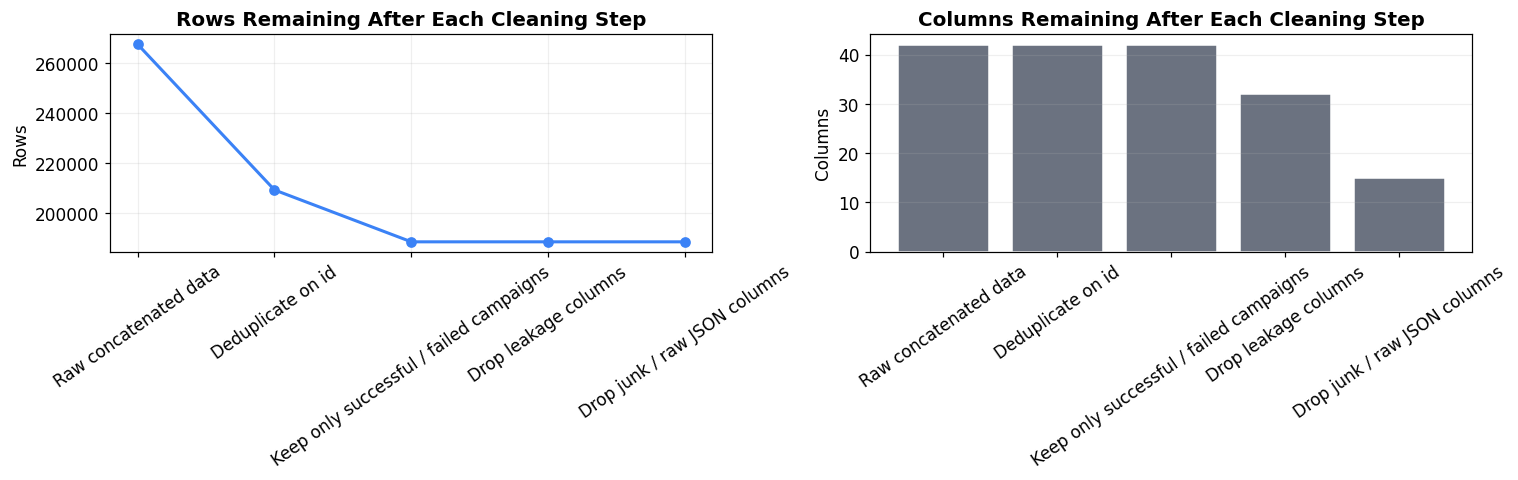

Final retained rows vs raw data: 70.4%


In [4]:
if raw_files:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    axes[0].plot(drop_audit["step"], drop_audit["rows_remaining"], marker="o", lw=2, color=SUCCESS_COLOR)
    axes[0].set_title("Rows Remaining After Each Cleaning Step", fontweight="bold")
    axes[0].set_ylabel("Rows")
    axes[0].tick_params(axis="x", rotation=35)
    axes[0].grid(alpha=0.2)

    axes[1].bar(drop_audit["step"], drop_audit["cols_remaining"], color=NEUTRAL_COLOR, edgecolor="white")
    axes[1].set_title("Columns Remaining After Each Cleaning Step", fontweight="bold")
    axes[1].set_ylabel("Columns")
    axes[1].tick_params(axis="x", rotation=35)
    axes[1].grid(axis="y", alpha=0.2)

    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_PATH, "00_drop_audit.png"), dpi=150, bbox_inches="tight")
    plt.show()

    final_row_retention = drop_audit.iloc[-1]["row_retention_pct"]
    print(f"Final retained rows vs raw data: {final_row_retention:.1f}%")

### Interpretation

The data drop is **not arbitrary**. Each removal step improves the validity of the supervised learning problem:

- removing duplicates avoids **double counting** the same campaign,
- keeping only `successful` and `failed` projects makes the target **well-defined**,
- dropping leakage variables protects us from **inflated model performance**,
- and removing junk / raw JSON columns keeps the pipeline **simpler and more reproducible**.

This is exactly the kind of cleaning that reduces noise **without weakening the business question**.

## Section 3 — Missing Values and Imputation Logic

Missingness is not only a technical issue; it often carries **domain meaning**.  
So instead of using one blanket rule, we separate variables into cases:

- **Missing means absence** → e.g. no video attached, no text entered.
- **Missing is rare noise** → safe to impute with a simple default.
- **Missing is structural** → e.g. `loc_state` missing for many non-US projects, which changes how we model geography.

In [5]:
missing_audit = (
    pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_missing": df.isna().sum(),
        "pct_missing": (100 * df.isna().mean()).round(2),
        "n_unique": df.nunique(dropna=True)
    })
    .sort_values(["pct_missing", "n_missing"], ascending=False)
)

missing_audit.head(20)

,dtype,n_missing,pct_missing,n_unique
video,object,62016,32.9100,126413
blurb,object,0,0.0000,185969
country,object,0,0.0000,25
created_at,int64,0,0.0000,188371
currency,object,0,0.0000,15
deadline,int64,0,0.0000,178841
disable_communication,bool,0,0.0000,2
goal,float64,0,0.0000,6268
id,int64,0,0.0000,188429
launched_at,int64,0,0.0000,188210


In [6]:
# Human-readable imputation plan aligned with Notebook 03
imputation_plan = pd.DataFrame([
    {"variable_group": "goal", "imputation": "Fill missing with 0 before log1p", "why": "Campaign goal should exist; missing is rare and 0 is a conservative fallback before transformation."},
    {"variable_group": "blurb / name text", "imputation": "Fill missing with empty string", "why": "Missing text behaves like absence of textual information and lets us compute length features cleanly."},
    {"variable_group": "video", "imputation": "Treat missing as 'no video' (0)", "why": "The absence of a video field is informative rather than random."},
    {"variable_group": "staff_pick", "imputation": "Map missing to 0 only for auditing", "why": "Missing is interpreted as not staff-picked, but the variable is later removed from the recommended modelling set."},
    {"variable_group": "cat_parent_name", "imputation": "Fill missing with 'Unknown'", "why": "Keeps the observation while preserving missingness as a category."},
    {"variable_group": "country", "imputation": "Fill rare / missing with 'Other' or global mean in encoders", "why": "Prevents sparse categories from dominating the model."},
    {"variable_group": "loc_state", "imputation": "Do not force full imputation into many categories", "why": "Missing is partly structural for non-US campaigns, so a coarse feature is safer than full state OHE."},
], columns=["variable_group", "imputation", "why"])

imputation_plan

,variable_group,imputation,why
0,goal,Fill missing with 0 before log1p,Campaign goal should exist; missing is rare an...
1,blurb / name text,Fill missing with empty string,Missing text behaves like absence of textual i...
2,video,Treat missing as 'no video' (0),The absence of a video field is informative ra...
3,staff_pick,Map missing to 0 only for auditing,"Missing is interpreted as not staff-picked, bu..."
4,cat_parent_name,Fill missing with 'Unknown',Keeps the observation while preserving missing...
5,country,Fill rare / missing with 'Other' or global mea...,Prevents sparse categories from dominating the...
6,loc_state,Do not force full imputation into many categories,Missing is partly structural for non-US campai...


### Decision Summary

We **do not overcomplicate imputation**.  
Given the size of the dataset, simple and interpretable defaults are preferable to fancy methods that add complexity but little value.

That is why the final pipeline relies on:
- zeros for true absence,
- empty strings for text,
- `"Unknown"` / `"Other"` for sparse categories,
- and training-only statistics for encoded features.

This is a strong trade-off between **clarity, reproducibility, and model robustness**.

## Section 4 — Target Variable Distribution

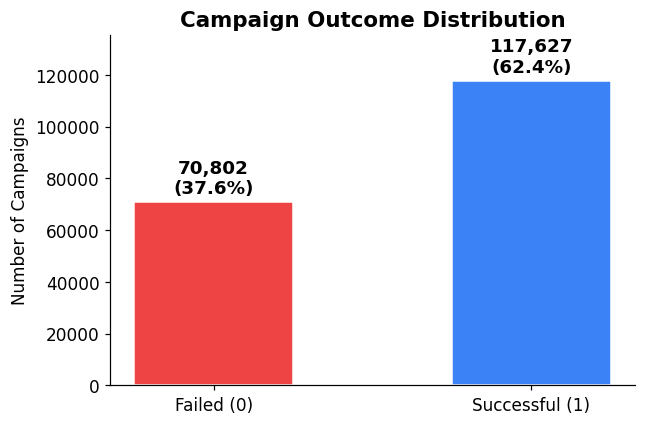

Baseline success rate: 62.4%


In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
vc = df["success"].value_counts().sort_index()
labels = ["Failed (0)", "Successful (1)"]
colors = [FAILURE_COLOR, SUCCESS_COLOR]

bars = ax.bar(labels, vc.values, color=colors, edgecolor="white", width=0.5)
for bar, val in zip(bars, vc.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + vc.max() * 0.015,
        f"{val:,}\n({val / len(df) * 100:.1f}%)",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=12
    )

ax.set_title("Campaign Outcome Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Campaigns")
ax.set_ylim(0, vc.max() * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "01_target_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Baseline success rate: {pct(df['success'].mean())}")

The target is **not perfectly balanced**, but it is not extremely imbalanced either.  
This matters because it justifies using metrics such as **ROC-AUC, PR-AUC, precision, recall, and F1**, rather than relying on accuracy alone.

## Section 5 — Temporal Patterns and the Success-Rate Drop

A central business question is whether the platform behaves the same over time.  
If success dynamics changed materially, then mixing very early campaigns with later ones may create a **distribution-shift problem**.

This matters for two reasons:

1. **Business reasoning**: Kickstarter in its early years was a different marketplace — fewer campaigns, different creator behaviour, and less competition.
2. **Modelling reasoning**: training on pre-drop data can make the model learn patterns that no longer represent the current platform.

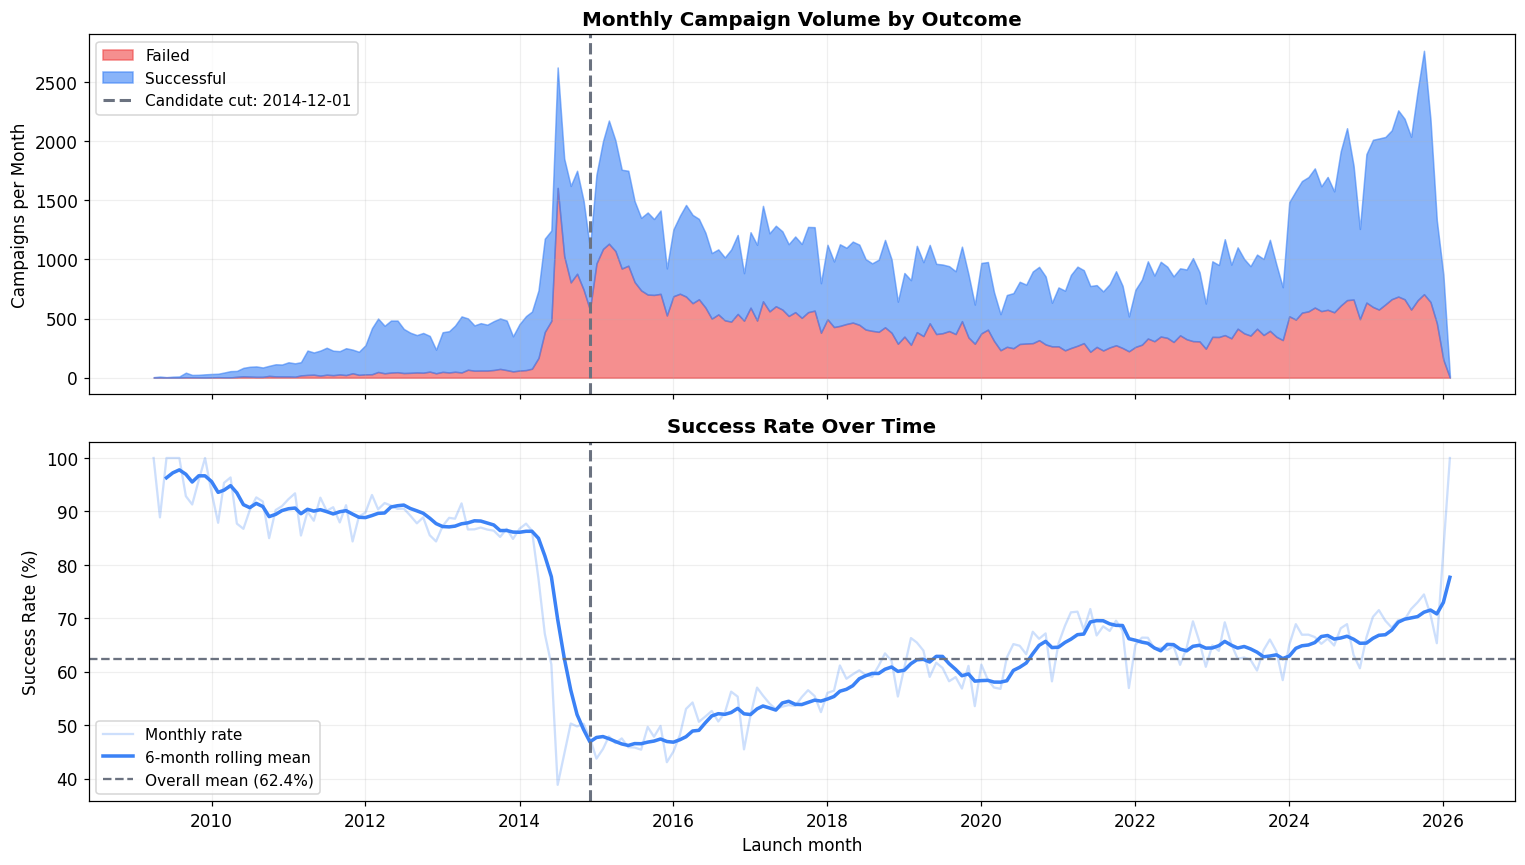

Candidate success-rate drop month : 2014-12-01
Pre-drop success rate             : 71.7%
Post-drop success rate            : 60.8%
Difference                        : -10.9 percentage points


In [8]:
df["year_month"] = df["launched_dt"].dt.to_period("M")
monthly = df.groupby(["year_month", "success"]).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()

monthly_total = monthly.sum(axis=1)
monthly_success_rate = monthly.get(1, pd.Series(0, index=monthly.index)) / monthly_total
monthly_success_rate_6m = monthly_success_rate.rolling(6, min_periods=3).mean()

# Compare each month to the smoothed value 12 months earlier
change_vs_12m_ago = monthly_success_rate_6m - monthly_success_rate_6m.shift(12)

# Ignore the very beginning of the platform to reduce noisy early months
candidate_window = change_vs_12m_ago.iloc[24:].dropna()
drop_month = candidate_window.idxmin() if len(candidate_window) else monthly.index.min()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Campaign volume
axes[0].fill_between(monthly.index, monthly.get(0, 0), alpha=0.60, color=FAILURE_COLOR, label="Failed")
axes[0].fill_between(
    monthly.index,
    monthly.get(0, 0),
    monthly.get(0, 0) + monthly.get(1, 0),
    alpha=0.60,
    color=SUCCESS_COLOR,
    label="Successful"
)
axes[0].axvline(drop_month, color=NEUTRAL_COLOR, linestyle="--", lw=2, label=f"Candidate cut: {drop_month.date()}")
axes[0].set_title("Monthly Campaign Volume by Outcome", fontweight="bold")
axes[0].set_ylabel("Campaigns per Month")
axes[0].legend()
axes[0].grid(alpha=0.2)

# Success rate over time
axes[1].plot(monthly.index, monthly_success_rate * 100, alpha=0.25, color=SUCCESS_COLOR, label="Monthly rate")
axes[1].plot(monthly.index, monthly_success_rate_6m * 100, color=SUCCESS_COLOR, lw=2.3, label="6-month rolling mean")
axes[1].axhline(df["success"].mean() * 100, color=NEUTRAL_COLOR, linestyle="--", label=f"Overall mean ({df['success'].mean()*100:.1f}%)")
axes[1].axvline(drop_month, color=NEUTRAL_COLOR, linestyle="--", lw=2)
axes[1].set_title("Success Rate Over Time", fontweight="bold")
axes[1].set_ylabel("Success Rate (%)")
axes[1].set_xlabel("Launch month")
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "02_temporal_patterns.png"), dpi=150, bbox_inches="tight")
plt.show()

pre_drop_mask = df["launched_dt"] < pd.Timestamp(drop_month, tz="UTC")
post_drop_mask = ~pre_drop_mask

pre_drop_rate = df.loc[pre_drop_mask, "success"].mean()
post_drop_rate = df.loc[post_drop_mask, "success"].mean()

print(f"Candidate success-rate drop month : {drop_month.date()}")
print(f"Pre-drop success rate             : {pre_drop_rate*100:.1f}%")
print(f"Post-drop success rate            : {post_drop_rate*100:.1f}%")
print(f"Difference                        : {(post_drop_rate - pre_drop_rate)*100:.1f} percentage points")

### Business Interpretation of the Drop

If the chart shows a clear and sustained fall in success rate, then the earliest period behaves like a **different marketplace regime**.

A sensible business interpretation is:
- early Kickstarter campaigns benefited from a **less crowded platform**,
- later campaigns competed in a **more saturated environment**,
- and creator / backer behaviour evolved with the platform.

Because our goal is to build a model that is useful for **current or recent campaigns**, it is reasonable to **drop pre-drop data** and focus modelling on the more stable regime after the structural change.

In [9]:
# Recommended filtered window for downstream modelling or sensitivity checks
df_post_drop = df.loc[post_drop_mask].copy()

post_drop_summary = pd.DataFrame({
    "dataset": ["Full cleaned data", "Post-drop subset"],
    "rows": [len(df), len(df_post_drop)],
    "success_rate": [df["success"].mean(), df_post_drop["success"].mean()],
    "start_date": [df["launched_dt"].min().date(), df_post_drop["launched_dt"].min().date()],
    "end_date": [df["launched_dt"].max().date(), df_post_drop["launched_dt"].max().date()],
})
post_drop_summary["success_rate"] = (100 * post_drop_summary["success_rate"]).round(2)
post_drop_summary

,dataset,rows,success_rate,start_date,end_date
0,Full cleaned data,188429,62.4300,2009-04-25,2026-02-06
1,Post-drop subset,160761,60.8200,2014-12-01,2026-02-06


In [10]:
# Optional: save the recommended post-drop modelling window
post_drop_path = os.path.join(OUTPUTS_PATH, "clean_df_post_drop.parquet")
df_post_drop.to_parquet(post_drop_path, index=False)
print(f"Saved recommended post-drop dataset to: {post_drop_path}")

Saved recommended post-drop dataset to: data/clean_df_post_drop.parquet


## Section 6 — Goal Amount Analysis

Campaign goal is one of the most important business variables in the whole project.  
It is heavily right-skewed, so we analyse it on a log scale.

The hypothesis is intuitive: campaigns asking for much more money are harder to fund successfully.

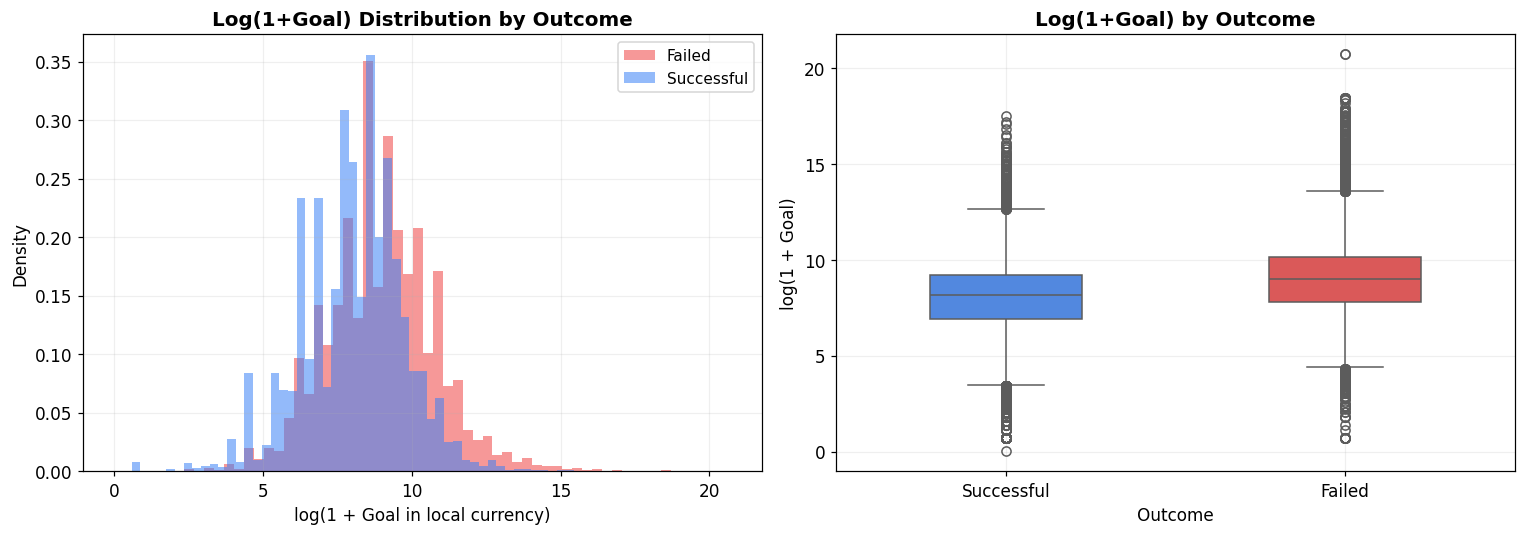

Median goal — Successful : 3,500
Median goal — Failed     : 8,000
Failed / Successful ratio: 2.29x


In [11]:
df["log_goal"] = np.log1p(df["goal"].clip(lower=0))
success_goals = df.loc[df["success"] == 1, "log_goal"].dropna()
failure_goals = df.loc[df["success"] == 0, "log_goal"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(failure_goals, bins=60, alpha=0.55, color=FAILURE_COLOR, label="Failed", density=True)
axes[0].hist(success_goals, bins=60, alpha=0.55, color=SUCCESS_COLOR, label="Successful", density=True)
axes[0].set_title("Log(1+Goal) Distribution by Outcome", fontweight="bold")
axes[0].set_xlabel("log(1 + Goal in local currency)")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(alpha=0.2)

plot_data = df[["log_goal", "success"]].dropna().copy()
plot_data["Outcome"] = plot_data["success"].map({1: "Successful", 0: "Failed"})
sns.boxplot(
    data=plot_data,
    x="Outcome",
    y="log_goal",
    palette={"Successful": SUCCESS_COLOR, "Failed": FAILURE_COLOR},
    ax=axes[1],
    width=0.45
)
axes[1].set_title("Log(1+Goal) by Outcome", fontweight="bold")
axes[1].set_ylabel("log(1 + Goal)")
axes[1].grid(alpha=0.2)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "03_goal_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()

med_success = np.expm1(success_goals.median())
med_failure = np.expm1(failure_goals.median())

print(f"Median goal — Successful : {med_success:,.0f}")
print(f"Median goal — Failed     : {med_failure:,.0f}")
print(f"Failed / Successful ratio: {med_failure / med_success:.2f}x")

The goal variable clearly deserves a transformation.  
This directly motivates the `log_goal` feature engineered in Notebook 03.

## Section 7 — Category Analysis

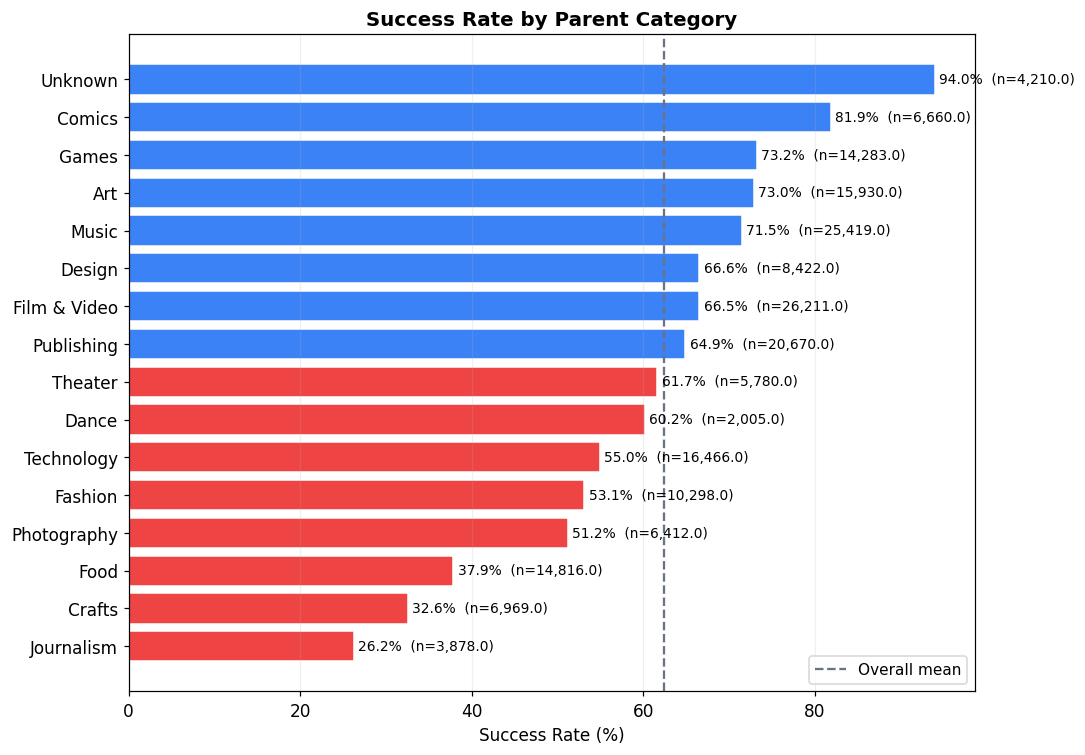

,n_success,n_total,success_rate
cat_parent_name,,,
Unknown,3958,4210,0.9401
Comics,5455,6660,0.8191
Games,10462,14283,0.7325
Art,11621,15930,0.7295
Music,18184,25419,0.7154
Design,5605,8422,0.6655
Film & Video,17443,26211,0.6655
Publishing,13422,20670,0.6493


In [12]:
cat_stats = (
    df.groupby("cat_parent_name")["success"]
      .agg(["sum", "count", "mean"])
      .rename(columns={"sum": "n_success", "count": "n_total", "mean": "success_rate"})
      .dropna()
      .sort_values("success_rate", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    cat_stats.index,
    cat_stats["success_rate"] * 100,
    color=[SUCCESS_COLOR if r > df["success"].mean() else FAILURE_COLOR for r in cat_stats["success_rate"]],
    edgecolor="white"
)

for bar, (_, row) in zip(bars, cat_stats.iterrows()):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{row['success_rate']*100:.1f}%  (n={row['n_total']:,})",
        va="center",
        fontsize=9
    )

ax.axvline(df["success"].mean() * 100, color=NEUTRAL_COLOR, linestyle="--", label="Overall mean")
ax.set_title("Success Rate by Parent Category", fontweight="bold")
ax.set_xlabel("Success Rate (%)")
ax.legend()
ax.grid(axis="x", alpha=0.2)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "04_category_success_rate.png"), dpi=150, bbox_inches="tight")
plt.show()

cat_stats.sort_values("success_rate", ascending=False).head(8)

Category effects are large enough to justify keeping category information in the feature set.  
This is why Notebook 03 uses:
- **target encoding** for `cat_name`,
- and **one-hot encoding** for the smaller parent-category field.

## Section 8 — Staff Pick: Keep It or Remove It?

`staff_pick` is extremely predictive, so it deserves special treatment.  
But predictive power alone is **not** enough to justify including a feature.

The real question is:

> **Would this variable be available at the moment we want to make the prediction?**

If the answer is no, then it should not be part of the final modelling set.

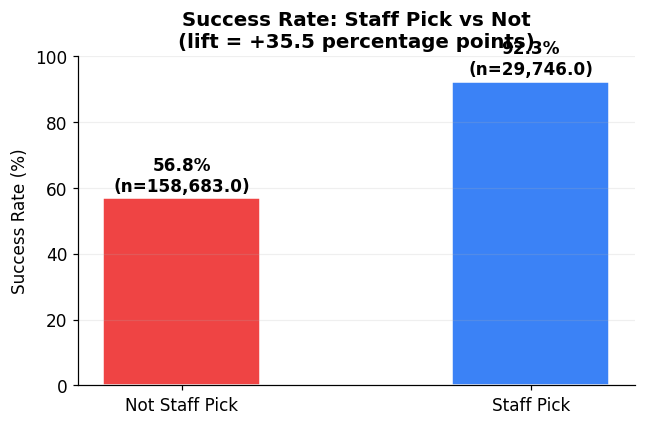

Staff pick success rate : 92.3%
Non-staff pick rate     : 56.8%
Lift                    : +35.5 percentage points


In [13]:
sp = df["staff_pick"].map({"True": 1, "False": 0, True: 1, False: 0}).fillna(0).astype(int)
df["staff_pick_int"] = sp

sp_stats = df.groupby("staff_pick_int")["success"].agg(["sum", "count", "mean"])
sp_stats.index = ["Not Staff Pick", "Staff Pick"]

rate_sp = sp_stats.loc["Staff Pick", "mean"]
rate_nonsp = sp_stats.loc["Not Staff Pick", "mean"]
lift = (rate_sp - rate_nonsp) * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    sp_stats.index,
    sp_stats["mean"] * 100,
    color=[FAILURE_COLOR, SUCCESS_COLOR],
    edgecolor="white",
    width=0.45
)

for bar, (_, row) in zip(bars, sp_stats.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{row['mean']*100:.1f}%\n(n={row['count']:,})",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

ax.set_title(f"Success Rate: Staff Pick vs Not\n(lift = +{lift:.1f} percentage points)", fontweight="bold")
ax.set_ylabel("Success Rate (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_PATH, "05_staff_pick.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Staff pick success rate : {rate_sp*100:.1f}%")
print(f"Non-staff pick rate     : {rate_nonsp*100:.1f}%")
print(f"Lift                    : +{lift:.1f} percentage points")

### Decision

We **recommend removing `staff_pick` from the final predictive feature set**, even though it is highly predictive.

Why?

- It is an **editorial platform decision**, not an intrinsic campaign characteristic.
- In many real prediction settings, `staff_pick` may be assigned **after** campaign review, meaning the model would be using a signal that is not available at the creator's decision point.
- It risks behaving like **soft leakage**: not as direct as `pledged` or `backers_count`, but still too close to the platform's own judgment.

So the right analytical stance is:

- keep it in EDA to show that it matters,
- but **drop it from the recommended deployable model**.

## Section 9 — Is Location Important? Is Country Important? What About State?

Geography can matter, but location features are tricky:

- they may capture real differences in **market size, language, and platform maturity**,
- but they can also encode **bias** and reduce generalisability.

So we analyse geography at two levels:
1. **country**,
2. and **state-level** signal for US campaigns.

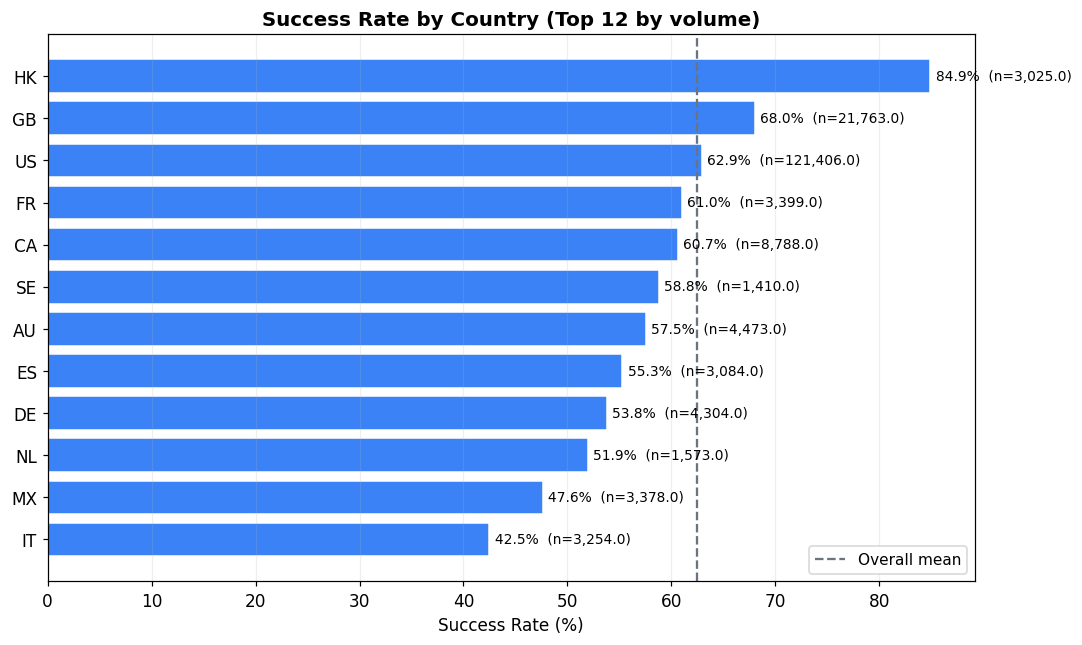

,n_campaigns,success_rate
country,,
US,121406,0.6290
GB,21763,0.6804
CA,8788,0.6066
AU,4473,0.5755
DE,4304,0.5376
FR,3399,0.6099
MX,3378,0.4760
IT,3254,0.4250
ES,3084,0.5529


In [14]:
geo_col = "country" if "country" in df.columns else ("loc_country" if "loc_country" in df.columns else None)

if geo_col is None:
    print("No country column found in the cleaned dataframe.")
else:
    country_stats = (
        df.groupby(geo_col)["success"]
          .agg(["count", "mean"])
          .rename(columns={"count": "n_campaigns", "mean": "success_rate"})
          .sort_values("n_campaigns", ascending=False)
    )

    top_countries = country_stats.head(12).sort_values("success_rate")

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top_countries.index, top_countries["success_rate"] * 100, color=SUCCESS_COLOR, edgecolor="white")
    for bar, (_, row) in zip(bars, top_countries.iterrows()):
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height()/2,
            f"{row['success_rate']*100:.1f}%  (n={row['n_campaigns']:,})",
            va="center",
            fontsize=9
        )
    ax.axvline(df["success"].mean() * 100, color=NEUTRAL_COLOR, linestyle="--", label="Overall mean")
    ax.set_title(f"Success Rate by {geo_col.title()} (Top 12 by volume)", fontweight="bold")
    ax.set_xlabel("Success Rate (%)")
    ax.legend()
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_PATH, "06_country_success_rate.png"), dpi=150, bbox_inches="tight")
    plt.show()

    display(country_stats.head(15))

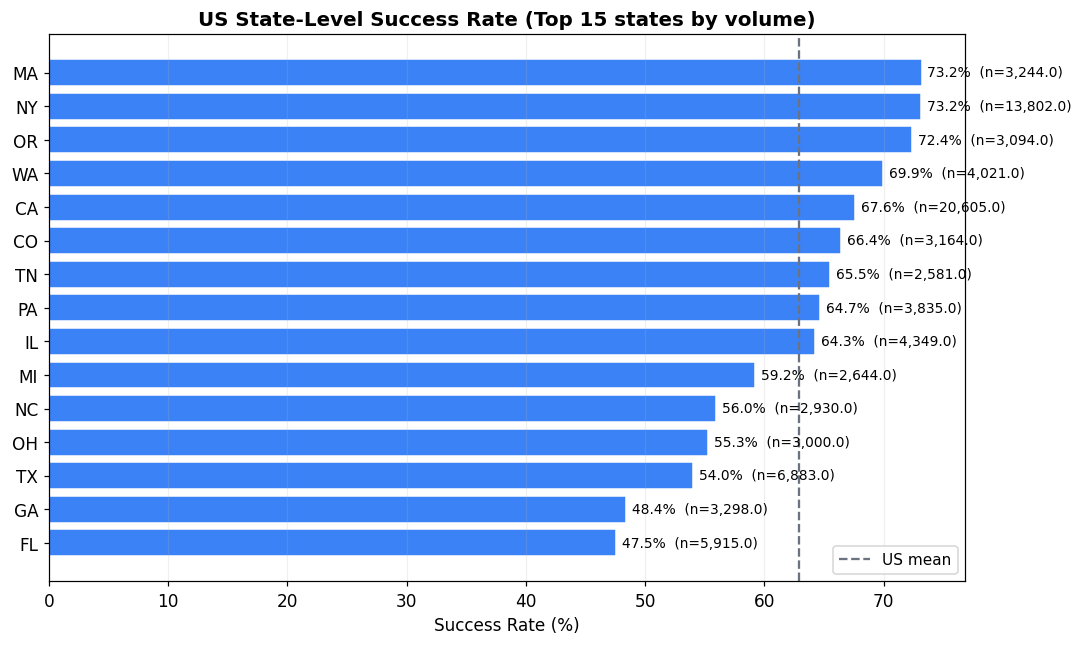

California success rate: 67.6% (n=20,605)
US overall success rate: 62.9%


,n_campaigns,success_rate
loc_state,,
CA,20605,0.6760
NY,13802,0.7318
TX,6883,0.5400
FL,5915,0.4754
IL,4349,0.6427
WA,4021,0.6993
PA,3835,0.6469
GA,3298,0.4839
MA,3244,0.7318


In [15]:
# State-level analysis, focusing on the US if location fields are available
state_col = "loc_state" if "loc_state" in df.columns else None

if geo_col is not None and state_col is not None:
    us_mask = df[geo_col].astype(str).str.upper().eq("US")
    us_df = df.loc[us_mask].copy()

    if len(us_df) > 0:
        state_stats = (
            us_df.groupby(state_col)["success"]
                 .agg(["count", "mean"])
                 .rename(columns={"count": "n_campaigns", "mean": "success_rate"})
                 .dropna()
                 .sort_values("n_campaigns", ascending=False)
        )

        top_states = state_stats.head(15).sort_values("success_rate")

        fig, ax = plt.subplots(figsize=(10, 6))
        bars = ax.barh(top_states.index.astype(str), top_states["success_rate"] * 100, color=SUCCESS_COLOR, edgecolor="white")
        for bar, (_, row) in zip(bars, top_states.iterrows()):
            ax.text(
                bar.get_width() + 0.5,
                bar.get_y() + bar.get_height()/2,
                f"{row['success_rate']*100:.1f}%  (n={row['n_campaigns']:,})",
                va="center",
                fontsize=9
            )
        ax.axvline(us_df["success"].mean() * 100, color=NEUTRAL_COLOR, linestyle="--", label="US mean")
        ax.set_title("US State-Level Success Rate (Top 15 states by volume)", fontweight="bold")
        ax.set_xlabel("Success Rate (%)")
        ax.legend()
        ax.grid(axis="x", alpha=0.2)
        plt.tight_layout()
        fig.savefig(os.path.join(FIGURES_PATH, "07_us_state_success_rate.png"), dpi=150, bbox_inches="tight")
        plt.show()

        california_rate = np.nan
        california_count = 0
        if "CA" in state_stats.index:
            california_rate = state_stats.loc["CA", "success_rate"]
            california_count = state_stats.loc["CA", "n_campaigns"]
            print(f"California success rate: {california_rate*100:.1f}% (n={california_count:,})")
            print(f"US overall success rate: {us_df['success'].mean()*100:.1f}%")

        display(state_stats.head(15))
    else:
        print("No US campaigns available for state-level analysis.")
else:
    print("State-level analysis skipped because loc_state or country is not available.")

### Location Decision

The geography plots usually show that **country matters**, but not all geographic detail is equally useful.

A practical and defensible decision is:
- keep **country** at a coarse level,
- avoid high-cardinality state encoding unless the evidence is very strong,
- and, if needed, keep one targeted feature such as **`is_california`** rather than one-hot encoding every state.

That is exactly why Notebook 03 uses a compact geographic representation instead of a huge state matrix.

## Section 10 — More EDA to Motivate Feature Engineering

To make the notebook more useful, we go one step further and inspect patterns that directly motivate the engineered features used later:

- campaign duration,
- creator preparation time,
- text length,
- and the presence of a video.

In [16]:
eda_features = df.copy()

if {"deadline", "launched_at"}.issubset(eda_features.columns):
    eda_features["duration_days"] = ((eda_features["deadline"] - eda_features["launched_at"]) / 86400).clip(lower=0)

if {"created_at", "launched_at"}.issubset(eda_features.columns):
    eda_features["prep_days"] = ((eda_features["launched_at"] - eda_features["created_at"]) / 86400).clip(lower=0)

if "blurb" in eda_features.columns:
    eda_features["blurb_length"] = eda_features["blurb"].fillna("").str.len()

if "video" in eda_features.columns:
    eda_features["has_video"] = eda_features["video"].notna().astype(int)

feature_candidates = [c for c in ["duration_days", "prep_days", "blurb_length", "has_video", "log_goal"] if c in eda_features.columns]
eda_features[feature_candidates + ["success"]].describe().T

,count,mean,std,min,25%,50%,75%,max
duration_days,188429.0000,33.1926,12.8086,1.0000,29.6667,30.0000,35.6480,120.5897
prep_days,188429.0000,54.7971,158.7844,0.0027,3.9886,14.2140,43.5493,4939.4527
blurb_length,188429.0000,104.7220,31.3048,0.0000,85.0000,117.0000,131.0000,151.0000
has_video,188429.0000,0.6709,0.4699,0.0000,0.0000,1.0000,1.0000,1.0000
log_goal,188429.0000,8.3771,1.8244,0.0100,7.3139,8.5174,9.5197,20.7233
success,188429.0000,0.6243,0.4843,0.0000,0.0000,1.0000,1.0000,1.0000


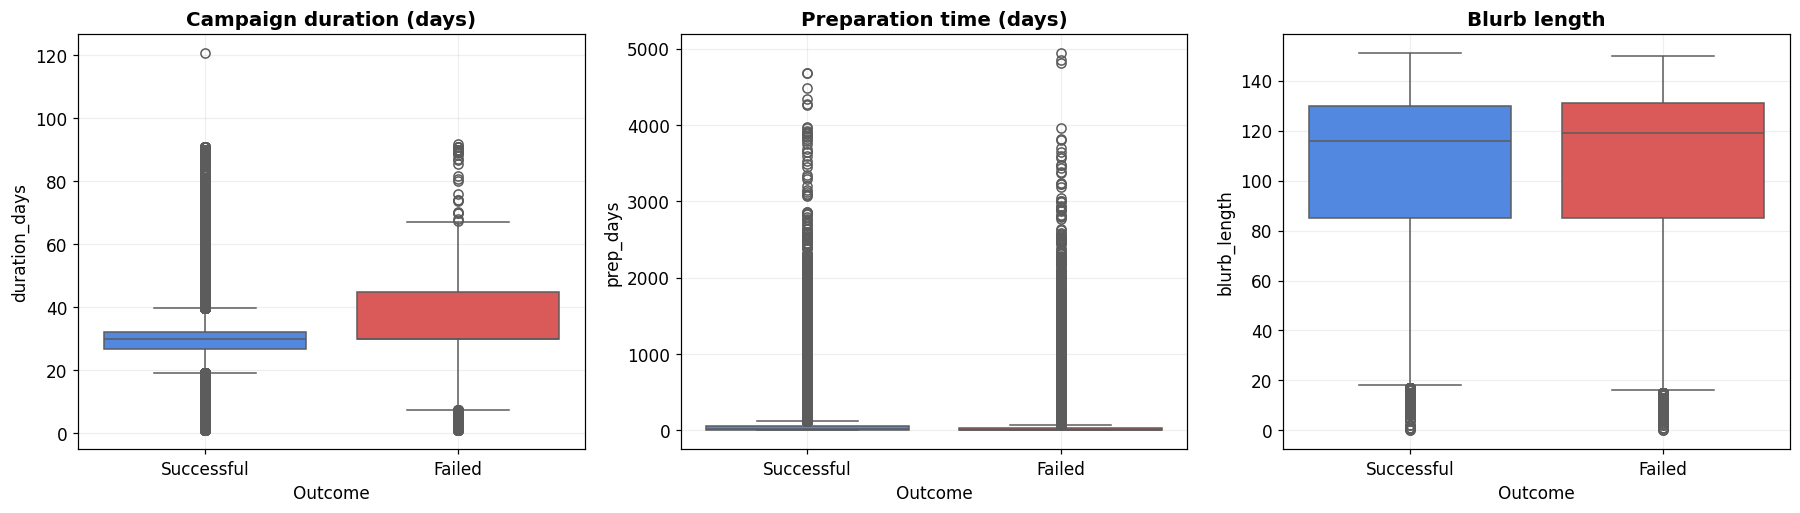

,count,mean
No video,62016,0.4965
Has video,126413,0.6869


In [17]:
plot_specs = [
    ("duration_days", "Campaign duration (days)"),
    ("prep_days", "Preparation time (days)"),
    ("blurb_length", "Blurb length"),
]

available_specs = [(col, label) for col, label in plot_specs if col in eda_features.columns]

if available_specs:
    fig, axes = plt.subplots(1, len(available_specs), figsize=(5.5 * len(available_specs), 4.8))
    if len(available_specs) == 1:
        axes = [axes]

    for ax, (col, label) in zip(axes, available_specs):
        plot_df = eda_features[[col, "success"]].dropna().copy()
        plot_df["Outcome"] = plot_df["success"].map({1: "Successful", 0: "Failed"})
        sns.boxplot(
            data=plot_df,
            x="Outcome",
            y=col,
            palette={"Successful": SUCCESS_COLOR, "Failed": FAILURE_COLOR},
            ax=ax
        )
        ax.set_title(label, fontweight="bold")
        ax.grid(alpha=0.2)

    plt.tight_layout()
    fig.savefig(os.path.join(FIGURES_PATH, "08_engineered_feature_patterns.png"), dpi=150, bbox_inches="tight")
    plt.show()

if "has_video" in eda_features.columns:
    video_stats = eda_features.groupby("has_video")["success"].agg(["count", "mean"])
    video_stats.index = ["No video", "Has video"]
    display(video_stats)

These patterns help justify several later design choices:

- **`duration_days`** because campaign length changes the fundraising challenge,
- **`prep_days`** because rushed launches may be weaker,
- **`blurb_length`** as a rough proxy for campaign effort / clarity,
- **`has_video`** because richer campaign presentation often helps conversion.

## Section 11 — Heatmap and Broader Pattern Scan

To avoid cherry-picking only a few variables, we also inspect numeric relationships more broadly.

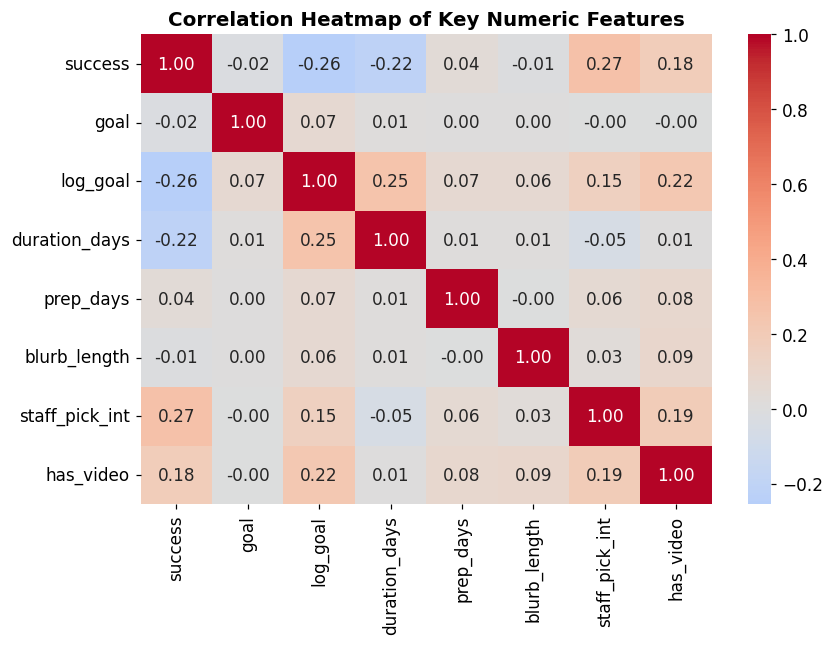

Correlation with success:
success           1.0000
staff_pick_int    0.2669
has_video         0.1847
prep_days         0.0368
blurb_length     -0.0076
goal             -0.0159
duration_days    -0.2160
log_goal         -0.2554
Name: success, dtype: float64


In [18]:
numeric_scan = eda_features.select_dtypes(include=np.number).copy()

# Keep a readable subset of columns for the heatmap
preferred_numeric_cols = [
    "success", "goal", "log_goal", "duration_days", "prep_days",
    "blurb_length", "name_length", "staff_pick_int", "has_video"
]
available_numeric_cols = [c for c in preferred_numeric_cols if c in numeric_scan.columns]

if len(available_numeric_cols) >= 3:
    corr = numeric_scan[available_numeric_cols].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=False)
    plt.title("Correlation Heatmap of Key Numeric Features", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_PATH, "09_heatmap_key_numeric_features.png"), dpi=150, bbox_inches="tight")
    plt.show()

    success_corr = corr["success"].sort_values(ascending=False)
    print("Correlation with success:")
    print(success_corr)
else:
    print("Not enough numeric columns available for a readable heatmap.")

The heatmap is not used to make simplistic causal claims.  
Its purpose is to show which variables have **strong enough signal** to justify deeper feature engineering and modelling attention.

## Section 12 — Quick Text Signal Scan (TF-IDF)

The project does not rely on a full NLP pipeline, but text is still informative.  
A lightweight TF-IDF scan helps us understand whether certain words or themes are disproportionately associated with successful versus failed campaigns.

In [19]:
if "blurb" in df.columns:
    text_df = df[["blurb", "success"]].copy()
    text_df["blurb"] = text_df["blurb"].fillna("").str.lower().str.strip()
    text_df = text_df[text_df["blurb"] != ""].copy()

    # Sample to keep runtime reasonable on very large datasets
    sample_n = min(len(text_df), 40000)
    text_df = text_df.sample(sample_n, random_state=42) if len(text_df) > sample_n else text_df

    tfidf = TfidfVectorizer(
        stop_words="english",
        max_features=500,
        ngram_range=(1, 1),
        min_df=10
    )
    X_tfidf = tfidf.fit_transform(text_df["blurb"])
    terms = np.array(tfidf.get_feature_names_out())

    success_mask = text_df["success"].values == 1
    fail_mask = ~success_mask

    mean_success = np.asarray(X_tfidf[success_mask].mean(axis=0)).ravel()
    mean_fail = np.asarray(X_tfidf[fail_mask].mean(axis=0)).ravel()
    diff = mean_success - mean_fail

    top_success_terms = pd.DataFrame({
        "term": terms[np.argsort(diff)[-15:][::-1]],
        "success_minus_fail_tfidf": np.sort(diff)[-15:][::-1]
    })
    top_fail_terms = pd.DataFrame({
        "term": terms[np.argsort(diff)[:15]],
        "success_minus_fail_tfidf": np.sort(diff)[:15]
    })

    print("Top terms more associated with successful campaigns:")
    display(top_success_terms)
    print("Top terms more associated with failed campaigns:")
    display(top_fail_terms)
else:
    print("Text column 'blurb' not available for TF-IDF scan.")

Top terms more associated with successful campaigns:


,term,success_minus_fail_tfidf
0,album,0.0122
1,new,0.0114
2,3d,0.0082
3,pins,0.0075
4,book,0.0075
5,enamel,0.0074
6,short,0.0070
7,stl,0.0069
8,collection,0.0066
9,featuring,0.0064


Top terms more associated with failed campaigns:


,term,success_minus_fail_tfidf
0,food,-0.0104
1,want,-0.0078
2,people,-0.0060
3,creating,-0.0055
4,create,-0.0054
5,platform,-0.0052
6,business,-0.0051
7,like,-0.0050
8,und,-0.0046
9,truck,-0.0046


This section is intentionally **lightweight**.  
The goal is not to build a full text model here, but to show that the campaign description contains real signal and therefore justifies simple text-derived features such as length and word count.

## Section 13 — Split and Stratification Audit

One of the requested methodological checks is to verify that **randomised procedures are stratified**.

Important nuance:
- the **main train/test split** from Notebook 01 is **temporal, not random**, because that is more realistic for a forecasting-style business problem;
- however, **any randomised resampling** used later (cross-validation, hyperparameter search, etc.) should be stratified to preserve the class balance.

In [20]:
# Audit the temporal 80/20 split used in Notebook 01
df_sorted = df.sort_values("launched_at").reset_index(drop=True)
cutoff_idx = int(len(df_sorted) * 0.80)

train_temporal = df_sorted.iloc[:cutoff_idx].copy()
test_temporal = df_sorted.iloc[cutoff_idx:].copy()

split_audit = pd.DataFrame({
    "split": ["Full data", "Temporal train (first 80%)", "Temporal test (last 20%)"],
    "rows": [len(df_sorted), len(train_temporal), len(test_temporal)],
    "success_rate": [
        df_sorted["success"].mean(),
        train_temporal["success"].mean(),
        test_temporal["success"].mean(),
    ]
})
split_audit["success_rate"] = (100 * split_audit["success_rate"]).round(2)
split_audit

,split,rows,success_rate
0,Full data,188429,62.4300
1,Temporal train (first 80%),150743,60.7400
2,Temporal test (last 20%),37686,69.1800


In [21]:
# Audit that the randomised folds are stratified
X_dummy = np.zeros((len(df), 1))
y = df["success"].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_rows = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_dummy, y), start=1):
    fold_rows.append({
        "fold": fold,
        "train_rows": len(train_idx),
        "valid_rows": len(valid_idx),
        "train_success_rate": 100 * y[train_idx].mean(),
        "valid_success_rate": 100 * y[valid_idx].mean(),
    })

fold_audit = pd.DataFrame(fold_rows).round(2)
fold_audit

,fold,train_rows,valid_rows,train_success_rate,valid_success_rate
0,1,150743,37686,62.4200,62.4300
1,2,150743,37686,62.4200,62.4300
2,3,150743,37686,62.4300,62.4200
3,4,150743,37686,62.4300,62.4200
4,5,150744,37685,62.4300,62.4300


### Split Decision

So the correct methodological statement is:

- **No**, the final evaluation split is **not stratified random** — it is **temporal by design**.
- **Yes**, the randomised procedures used later should be **stratified**, and the audit above confirms how to do that properly.

This is an important distinction to defend in the presentation and Q&A.

## Section 14 — Final EDA Summary

### Main takeaways

1. **The large data drop is justified**: duplicates, non-binary outcomes, leakage, and junk metadata all weaken the learning problem if left in.
2. **Missing values were imputed with simple, interpretable rules** rather than complicated methods that add little practical value.
3. **There is a meaningful success-rate drop over time**, which supports cutting pre-drop data when the goal is to model the modern platform.
4. **Goal amount, category, and text effort are clearly informative** and deserve engineered features.
5. **Location matters at country level**, but state-level detail should be handled carefully to avoid sparsity and overfitting.
6. **`staff_pick` should be removed from the recommended model** despite its predictive power, because it is too close to a platform-side decision.
7. **Randomised procedures should be stratified**, while the final holdout remains temporal for business realism.

Overall, this EDA does more than describe the data: it **justifies the modelling choices** that follow.

In [22]:
print("Notebook 02 (EDA) complete.")
print(f"Figures saved to: {os.path.abspath(FIGURES_PATH)}")
print(f"Post-drop dataset saved to: {os.path.abspath(os.path.join(OUTPUTS_PATH, 'clean_df_post_drop.parquet'))}")

Notebook 02 (EDA) complete.
Figures saved to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/notebooks_v2/data/figures
Post-drop dataset saved to: /Users/dacobri/Desktop/MSc Business Analytics/Classes Term 2/Artificial Intelligence 2/Final Project/Kickstarter_ML_Project/notebooks_v2/data/clean_df_post_drop.parquet
